In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from tqdm import tqdm

## Distribution of the plummer sphere

In [2]:
#Conversion in IU
G_p = 6.67259e-8 #G in cgs
M_sun = 1.9891e33 #solar mass in g
R_sun = 6.9598e10 #solar radius in cm 
year = 3.14159e7
ly = 9.463e17 #light year in cm
parsec = 3.086e18 #parsec in cm
AU = 1.496e13 #astronomical unit in cm

def v_IU(v_p, M_p=M_sun, r_p=AU):    #because 1 M_i = 1 M_sun and 1 r_i = 1 AU
    return np.sqrt(r_p / (G_p * M_p)) * v_p

def t_IU(t_p, M_p=M_sun, r_p=AU):
    return ((t_p / r_p)*(np.sqrt((G_p * M_p)/r_p)))

t_iu_yr = 6.251839 #1 yr is 6.251839 IU
v_iu_cgs = 3.357e-7 #1 cm/s is 3.357e-7 IU

N = 5000 #Number of particles of the plummer
N_syst = 5001
a = 3 #Plummer radius

M = 100 #Total mass in IU that corresponds to 5000 solar masses
M_i = M / N #Single particle mass, that is 1 IU

(0.0, 0.6)

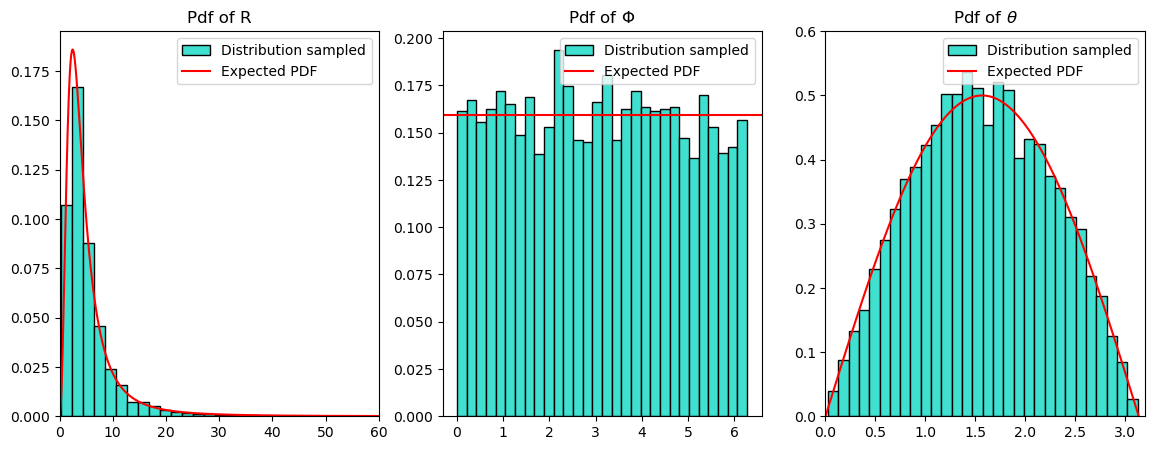

In [106]:
#Sample of the radii, phi and theta
P_r = np.random.uniform(0, 1, N)
r = a * (P_r**(-2/3) - 1)**(-1/2)

phi = np.random.uniform(0, 2*np.pi, N)

P_th=np.random.uniform(0, 1, N)
theta=[]
for i in range(0, N):
    theta=np.append(theta, np.arccos(1-2*P_th[i]))
    
x_grid_r = np.linspace(0, 100,1000)
x_grid_phi = np.linspace(0, 10, 100)
x_grid_th = np.linspace(0, 3.2, 100)

#Check the pdfs
fig, ax = plt.subplots(1, 3, figsize=(14,5))
ax[0].hist(r, bins=100, density = True, edgecolor='black', color='turquoise', label='Distribution sampled')
ax[0].set_title('Pdf of R')
ax[0].set_xlim(0, 60)
ax[0].plot(x_grid_r, (3*x_grid_r**2/a**3)*(1+x_grid_r**2/a**2)**(-5/2), color = 'red', label='Expected PDF')
ax[0].legend()

ax[1].hist(phi, bins=30, density = True, edgecolor='black', color='turquoise', label='Distribution sampled')
ax[1].set_title(r'Pdf of $\Phi$')
ax[1].axhline(1/(2*np.pi), color = 'red', label='Expected PDF')
ax[1].legend()

ax[2].hist(theta, bins=30, density = True, edgecolor='black', color='turquoise', label='Distribution sampled')
ax[2].set_title(r'Pdf of $\theta$')
ax[2].plot(x_grid_th, np.sin(x_grid_th)/2, color = 'red', label='Expected PDF')
ax[2].legend()
ax[2].set_xlim(0, 3.2)
ax[2].set_ylim(0, 0.6)

5000


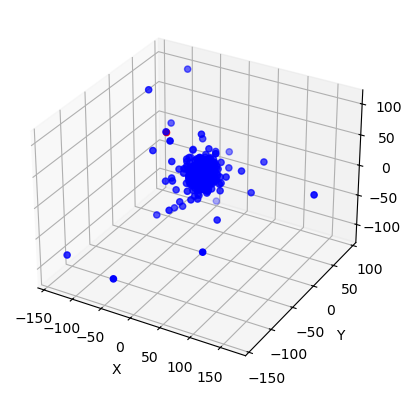

In [107]:
x_0=[]
y_0=[]
z_0=[]

#Converting the positions from spherical coords to cartesian ones 
for i in range(0, N):
    x_0=np.append(x_0, r[i]*np.sin(theta[i])*np.cos(phi[i]))
    y_0=np.append(y_0, r[i]*np.sin(theta[i])*np.sin(phi[i]))
    z_0=np.append(z_0, r[i]*np.cos(theta[i]))

#Showing the points
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_0, y_0, z_0, c='b', marker='o')
ax.scatter(x_0[-1], y_0[-1], z_0[-1], c='red', marker='o')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

print(len(x_0))

## Adding the perturbing particle
The situation we want to analyse is the one in which the perturbing particle has a mass M >> m of the single particle of the sphere (which is 0.02 M_sun), but M << Nm (so the total mass of the system which is 100 M_sun). We chose a mass M = 5 M_sun that corresponds to 5/0.02 = 250 IU. 
We set it at x = a (y=0, z=0), with the same velocity of the distribution. 

In [108]:
x_0=np.append(x_0, a) 
y_0=np.append(y_0, 0)
z_0=np.append(z_0, 0)
r=np.append(r, a)

masses = []
for i in range(N):
    masses = np.append(masses, 1/50)

masses= np.append(masses, 250)

In [90]:
len(x_0)

5001

In [91]:
len(masses)

5001

## Sampling the velocities

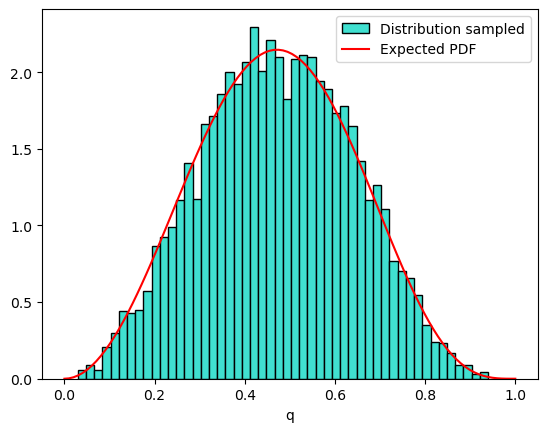

In [111]:
#Sample the velocities from the distribution function f(eps)

C_normalization = 0.04295146206444051 

f = lambda q: (1 - q**2)**(7/2) * q**2/C_normalization  #lambda function: defining a function without def, because we use it only here
max_f = np.max(f(np.linspace(0, 1, 1000)))
        
q_samples = []
        
while len(q_samples) < N_syst:
    q_rand = np.random.uniform(0, 1)
    y = np.random.uniform(0, max_f)
            
    if y < f(q_rand):
        q_samples.append(q_rand)

#Check the pdf of q
plt.hist(q_samples, bins=50, density=True, color='turquoise', label='Distribution sampled', edgecolor='black')
x_grid_q = np.linspace(0, 1, 100)
plt.plot(x_grid_q, f(x_grid_q), color='red', label='Expected PDF')
plt.xlabel('q')
plt.legend()

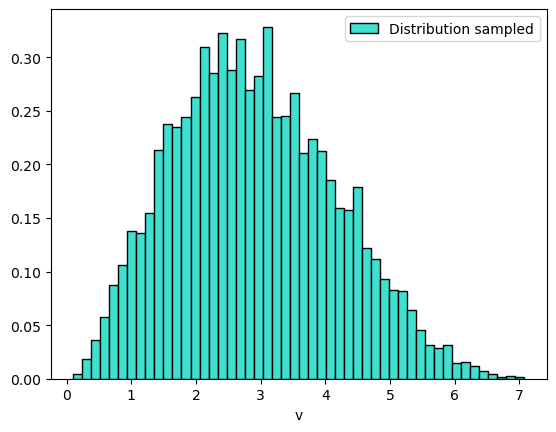

In [112]:
psi_IU = M / np.sqrt(r**2 + a**2) #Potential in IU
v = q_samples * np.sqrt(2 * psi_IU)
        
v_phi = 2 * np.pi * np.random.uniform(0, 1, N_syst)
v_theta = np.arccos(1 - 2 * np.random.uniform(0, 1, N_syst))  

vx_0 = v * np.cos(v_phi) * np.sin(v_theta)
vy_0 = v * np.sin(v_phi) * np.sin(v_theta)
vz_0 = v * np.cos(v_theta)

plt.hist(v, bins=50, density=True, color='turquoise', label='Distribution sampled', edgecolor='black')
#x_grid_q = np.linspace(0, 1, 100)
#plt.plot(x_grid_q, f(x_grid_q), color='red', label='Expected PDF')
plt.xlabel('v')
plt.legend()

In [113]:
#Compute the dynamical time 
r_mean = np.mean(r)
print('Mean radius:', r_mean)

density_mean = (3*M/(4*np.pi*a**3)) * (1 + (r_mean/a)**2)**(-5/2) #initial mean density
print('Mean initial density:', density_mean)

t_dyn_IU = np.sqrt(3 * np.pi / (16 * density_mean))  #G_i=1!
t_dyn = t_dyn_IU / t_iu_yr
print("Dynamical time: t_dyn =" + f"{t_dyn: .3f}" + " yr =" + f"{t_dyn_IU: .3f}" + " IU")

Mean radius: 5.861484548531222
Mean initial density: 0.017358244892921947
Dynamical time: t_dyn = 0.932 yr = 5.825 IU


## Create the input file

In [114]:
starting_time=0
num_dimensions=3

with open("Plummer5001.in", "w") as f:     
    print(N_syst, num_dimensions, starting_time, sep="\n", file=f)
    np.savetxt(f, np.column_stack([masses]), delimiter=" ")  
    np.savetxt(f, np.column_stack([x_0, y_0, z_0]), delimiter=" ")
    np.savetxt(f, np.column_stack([vx_0, vy_0, vz_0]), delimiter=" ")

In [115]:
len(v)

5001

Comand: ./treecode in=Plummer5001.in out=out_plum_pert_5001_01.out dtime=0.1 eps=0.1 theta=0.1 tstop=7 dtout=0.1 > energy_plum_pert_5001_01.log

# Analysis

In [11]:
#per il momento sono tutti in IU
def GetData(filename, N):
    file_output = open(filename, "r")
    output = file_output.read().splitlines()
    data = []
    time = []
    
    for i in range(3, len(output), 3 * N + 3):
        for j in range(N, 3 * N):
            data.append(output[i + j].split())
        
        time.append(float(output[i - 1]))
        
    #Convert the time in years
    #time = np.array(time) / t_iu_yr
    
    file_output.close()
    
    return np.array(data), np.array(time)

#Get the evolution in time from the data in the CM frame

def GetCoords(data, t, N):
    
    #Get the coordinates
    
    x_ext, y_ext, z_ext, x_pert, y_pert, z_pert  = [], [], [], [], [], []
    
    for i in range(0, len(t)):
        x_ext.append([])
        y_ext.append([])
        z_ext.append([])
        x_pert.append([])
        y_pert.append([])
        z_pert.append([])
        
        
    #Every row contains the coordinate of the i-th particle, every column contains its evolution in time
    
    row = 0
    
    for i in range(0, len(data), 2 * N):    
        for j in range(0, N-1):
            x_ext[row].append(float(data[i + j][0]))
            y_ext[row].append(float(data[i + j][1]))
            z_ext[row].append(float(data[i + j][2]))
            
        x_pert[row].append(float(data[i + N][0]))
        y_pert[row].append(float(data[i + N][1]))
        z_pert[row].append(float(data[i + N][2]))
        
        row += 1
    
    #Convert the coordinates to the CM frame
        
    x_ext = np.array(x_ext)
    y_ext = np.array(y_ext)
    z_ext = np.array(z_ext)

    x_pert = np.array(x_pert)
    y_pert = np.array(y_pert)
    z_pert = np.array(z_pert)

    x_CM = (M_i * np.sum(x_ext, axis=1) + 250*x_pert[:, 0]) / M   #le masse sono tutte uguali eccetto perturber
    y_CM = (M_i * np.sum(y_ext, axis=1) + 250*y_pert[:, 0])  / M
    z_CM = (M_i * np.sum(z_ext, axis=1) + 250*z_pert[:, 0]) / M
    r_CM = np.sqrt(x_CM**2 + y_CM**2 + z_CM**2)

    x_tot = np.concatenate((x_ext, x_pert), axis=1)
    y_tot = np.concatenate((y_ext, y_pert), axis=1)
    z_tot = np.concatenate((z_ext, z_pert), axis=1)
         
    x = x_tot - x_CM[:, np.newaxis]
    y = y_tot - y_CM[:, np.newaxis]
    z = z_tot - z_CM[:, np.newaxis]

    return x, y, z, x_CM, y_CM, z_CM, r_CM


#Get the velocities in time in the CM frame

def GetVelocities(data, t, N):
    
    #Get the coordinates
    
    vx_ext, vy_ext, vz_ext = [], [], []
    
    for i in range(0, len(t)):
        vx_ext.append([])
        vy_ext.append([])
        vz_ext.append([])
        
    #Every row contains the coordinate of the i-th particle, every column contains its evolution in time
    
    row = 0
    
    for i in range(N, len(data), 2 * N):    
        for j in range(0, N):
            vx_ext[row].append(float(data[i + j][0]))
            vy_ext[row].append(float(data[i + j][1]))
            vz_ext[row].append(float(data[i + j][2]))
        
        row += 1

    #Convert the coordinates to the CM frame
        
    vx_ext = np.array(vx_ext) #(len(t), N)
    vy_ext = np.array(vy_ext)
    vz_ext = np.array(vz_ext)
    
    vx_sum = np.zeros(len(t)) #(len(t), )
    vy_sum = np.zeros(len(t))
    vz_sum = np.zeros(len(t))
    
    for j in range(len(t)): 
        vx_sum[j] = np.sum(vx_ext[j][:-1])
        vy_sum[j] = np.sum(vy_ext[j][:-1])
        vz_sum[j] = np.sum(vz_ext[j][:-1])

    vx_CM = np.zeros(len(t)) #(len(t),)
    vy_CM = np.zeros(len(t))
    vz_CM = np.zeros(len(t))

    for i in range(len(t)):
        vx_CM[i] = (M_i * vx_sum[i] + 250*vx_ext[i][-1])/ M #(len(t),)
        vy_CM[i] = (M_i * vy_sum[i] + 250*vy_ext[i][-1]) / M
        vz_CM[i] = (M_i * vz_sum[i] + 250*vz_ext[i][-1]) / M
    
    K_CM = M * (vx_CM**2 + vy_CM**2 + vz_CM**2) / 2   #energia cinetica del centro di massa 
         
    vx = vx_ext - vx_CM[:, np.newaxis]   #(len(t), N)
    vy = vy_ext - vy_CM[:, np.newaxis]
    vz = vz_ext - vz_CM[:, np.newaxis]

    v_CM = np.sqrt(vx_CM**2 + vy_CM**2 + vz_CM**2)

    return vx, vy, vz, K_CM, v_CM

In [12]:
data, t = GetData("out_plum_pert_5001_01.out", N_syst)
x, y, z, x_CM, y_CM, z_CM, R_CM = GetCoords(data, t, N_syst)
vx, vy, vz, K_CM, v_CM = GetVelocities(data, t, N_syst)

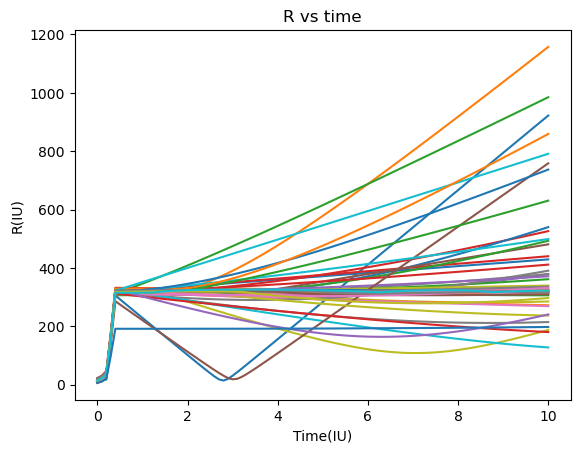

In [15]:
r = np.sqrt(x**2 + y**2 + z**2)
plt.title("R vs time")
plt.xlabel("Time(IU)")
plt.ylabel("R(IU)")

r_s = np.zeros(len(t))

for j in range(0, N_syst, 100):
    for i in range(len(t)):
        r_s[i] = r[i][j]
    plt.plot(t, r_s)

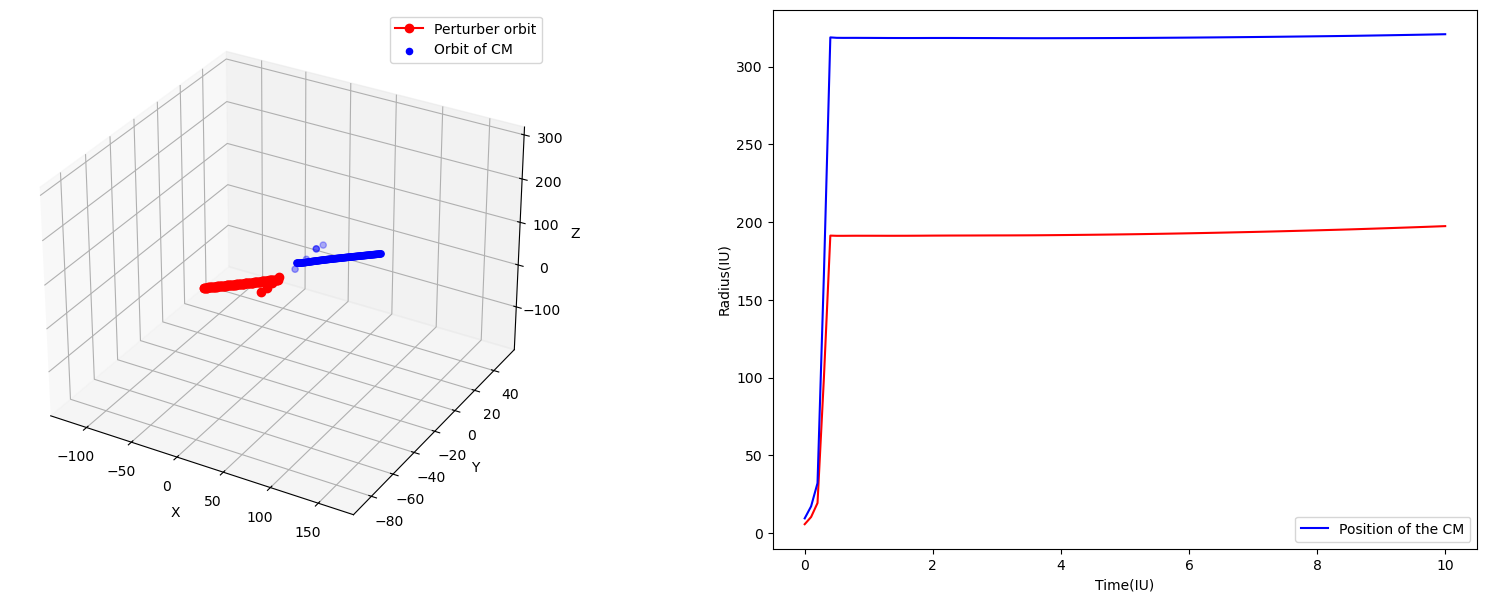

In [23]:
#Orbit of the massive particle 
r_M = np.zeros(len(t))
x_M = np.zeros(len(t))
y_M = np.zeros(len(t))
z_M = np.zeros(len(t))

for i in range(len(t)):
    x_M[i] = x[i][-1]
    y_M[i] = y[i][-1]
    z_M[i] = z[i][-1]
    r_M[i] = r[i][-1]

fig = plt.figure(figsize=(20, 7))

# Create a 3D subplot on the left
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot(x_M, y_M, z_M, c='red', marker='o', label='Perturber orbit')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.scatter(x_CM, y_CM, z_CM, color='blue', marker='o', label='Orbit of CM')
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(t, r_M, c='red')
ax2.set_xlabel('Time(IU)')
ax2.set_ylabel('Radius(IU)')
ax2.plot(t, R_CM, c='blue', label='Position of the CM')
ax2.legend()

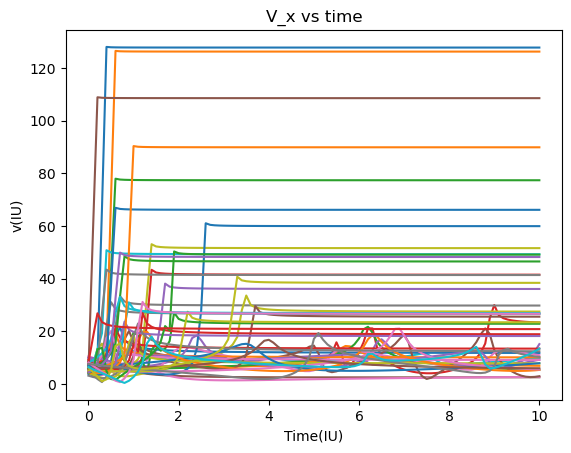

In [17]:
v = np.sqrt(vx**2 + vy**2 + vz**2)
plt.title("V_x vs time")
plt.xlabel("Time(IU)")
plt.ylabel("v(IU)")
v1 = np.zeros(len(t))
for j in range(0, N, 100):
    for i in range(len(t)):
        v1[i] = v[i][j]
    plt.plot(t, v1)

In [18]:
def GetEnergy(filename, N, K_CM):
    file_output = open(filename, "r")
    output = np.array(file_output.read().splitlines())
    
    idx = np.where(output == output[9])[0] #Find the row with T and U
    
    K = []
    U = []
    
    for i in idx:
        K.append(float(output[i + 1].split()[1]))
        U.append(-float(output[i + 1].split()[2]))
        
    K = (np.array(K) - K_CM) #* M_sun / v_iu_cgs**2
    U = np.array(U) #* G_p * M_sun**2 / AU

    E = K + U
    
    file_output.close()
    
    return E, K, U 
    
E, K, U = GetEnergy("energy_plum_pert_5001_01.log", N_syst, K_CM)

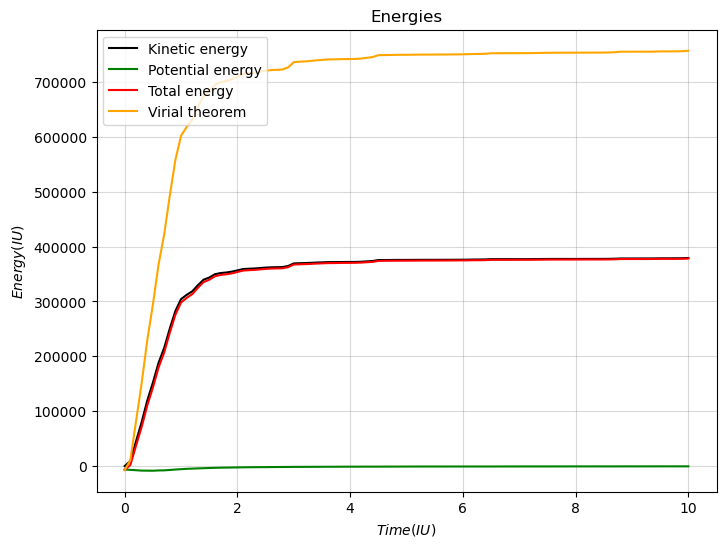

In [19]:
fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('$Time(IU)$')
ax1.set_ylabel('$Energy(IU)$')
ax1.plot(t, K, label = 'Kinetic energy', c= 'black')
ax1.plot(t, U, label = 'Potential energy', c= 'green')
ax1.plot(t, E, label = 'Total energy', c= 'red')
ax1.plot(t, 2*K+U, label = 'Virial theorem', c = 'orange')
ax1.set_title('Energies')
ax1.legend()

In [24]:
import os
import imageio.v2 as imageio

# Toggle on/off the movie maker
make_movie = True

if make_movie:
    # FOLDERS MANAGING
    movie_dir_path = "movie"
    frames_dir_path = os.path.join(movie_dir_path, "frames")
    movie_frame_name_prefix = "snapshot_img_"

    # Create folders to store the movie and its frames
    if not os.path.isdir(movie_dir_path):
        os.makedirs(frames_dir_path)
    
    # Empty the 'frames' folder
    for file_name in os.listdir(frames_dir_path):
        file_path = os.path.join(frames_dir_path, file_name)
        os.remove(file_path)
    
    # Empty the 'movie' folder
    for file_name in os.listdir(movie_dir_path):
        file_path = os.path.join(movie_dir_path, file_name)
        if os.path.isfile(file_path):
            os.remove(file_path)

    # GENERATING FRAMES
    N_frames = len(t)  # Assumiamo che "t" sia la lista dei tempi

    delete_frames = True  # Se vuoi i frames metti False

    fig = plt.figure(figsize=(16, 9))
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect(None, zoom=0.9)  # To prevent z-axis label from being cut off

    # For every snapshot (or for some of them depending on the step of the range() call)
    # plot the position of every particle in 3D space
    for i in range(0, N_frames, 5):
        for j in range(N):
            ax.scatter(x[i][j], y[i][j], z[i][j], color="blue", alpha =0.5)
        ax.scatter(x[i][N], y[i][N], z[i][N], color="red") 

        if i == 0:
            x_lim = ax.get_xlim()
            y_lim = ax.get_ylim()
            z_lim = ax.get_zlim()
        
        ax.set_aspect('equal', 'datalim')
        ax.set_xlim(x_lim)
        ax.set_ylim(y_lim)
        ax.set_zlim(z_lim)

        ax.set_xlabel("$x$")
        ax.set_ylabel("$y$")
        ax.set_zlabel("$z$")

        # Save the current figure with a proper name
        frame_name = movie_frame_name_prefix + str(i).zfill(5) + ".png"
        frame_path = os.path.join(frames_dir_path, frame_name)
        fig.savefig(frame_path)

        # Clear the axes for the next plot
        ax.clear()

    plt.close()

    # ASSEMBLING FRAMES
    movie_img_files = os.listdir(frames_dir_path)
    movie_img_files = sorted(movie_img_files)

    movie_path = os.path.join(movie_dir_path, "movie.mp4")

    # Use the imageio writer to build the movie by appending to it every frame
    # Default fps is 10
    with imageio.get_writer(movie_path, mode='I', fps=10) as writer:
        for filename in movie_img_files:
            image = imageio.imread(os.path.join(frames_dir_path, filename))  # Get the frame
            writer.append_data(image)  # Append the frame

    # Delete individual frames if requested
    if delete_frames:
        for file_name in os.listdir(frames_dir_path):
            file_path = os.path.join(frames_dir_path, file_name)
            os.remove(file_path)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1600, 900) to (1600, 912) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
